In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/kaggle/input/student-performance-dataset/Student_Performance.csv")

In [3]:
for col in df.columns:
    print(col)

student_id
age
gender
school_type
parent_education
study_hours
attendance_percentage
internet_access
travel_time
extra_activities
study_method
math_score
science_score
english_score
overall_score
final_grade


In [4]:
# Finding Null Values
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [5]:
# Finding Duplicates
duplicates = df[df.duplicated()]
print(duplicates)

       student_id  age  gender school_type parent_education  study_hours  \
15000        7271   15    male     private        no formal          1.8   
15001         861   19   other      public    post graduate          0.8   
15002        5391   15  female     private              phd          1.9   
15003       13419   16   other     private         graduate          0.7   
15004        5192   19  female      public    post graduate          4.9   
...           ...  ...     ...         ...              ...          ...   
24995       12047   17  female      public              phd          1.8   
24996        1102   16  female     private          diploma          2.7   
24997        4422   19   other     private    post graduate          1.0   
24998        7858   14    male     private          diploma          1.0   
24999       11621   18   other      public        no formal          0.7   

       attendance_percentage internet_access travel_time extra_activities  \
15000     

In [6]:
# FInd duplicate student of same ID
df[df['student_id'] == 861]

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
860,861,19,other,public,post graduate,0.8,98.3,no,15-30 min,no,coaching,54.3,45.4,51.5,53.9,e
15001,861,19,other,public,post graduate,0.8,98.3,no,15-30 min,no,coaching,54.3,45.4,51.5,53.9,e


In [7]:
print(df.duplicated().sum())
print(df.shape)

10000
(25000, 16)


In [8]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [9]:
print(df.duplicated().sum())
print(df.shape)

0
(15000, 16)


In [10]:
# Rename Columns
df.rename(columns={
    'math_score':'Math',
    'english_score':'English',
    'science_score':'Science'
},inplace=True)

In [11]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'Math', 'Science',
       'English', 'overall_score', 'final_grade'],
      dtype='object')

In [12]:
# Create New columns Average Score and calculate score in this
df['Average_Score']=(df['Math']+df['English']+df['Science'])/3

In [13]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,51.700000
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,63.733333
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b,86.333333
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,42.200000
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,23.866667


In [14]:
# Create function of performance for apply conditions in Average Score column
def performance(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

In [15]:
df['Performance']=df['Average_Score'].apply(performance)

In [16]:
df.head(40)

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,Math,Science,English,overall_score,final_grade,Average_Score,Performance
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,51.700000,Needs Improvement
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,63.733333,Needs Improvement
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b,86.333333,Good
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,42.200000,Needs Improvement
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,23.866667,Needs Improvement
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d,64.566667,Needs Improvement
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f,36.833333,Needs Improvement
7,8,18,female,private,post graduate,5.6,59.4,yes,>60 min,yes,group study,56.7,60.1,53.4,69.6,d,56.733333,Needs Improvement
8,9,15,other,private,high school,3.2,89.6,yes,15-30 min,yes,mixed,54.1,59.5,38.3,55.2,d,50.633333,Needs Improvement
9,10,14,female,public,diploma,6.8,62.4,yes,>60 min,no,mixed,71.9,70.4,81.3,69.6,d,74.533333,Average


In [17]:
# Saved Cleaned File
df.to_csv("cleaned_student_performance.csv", index=False)

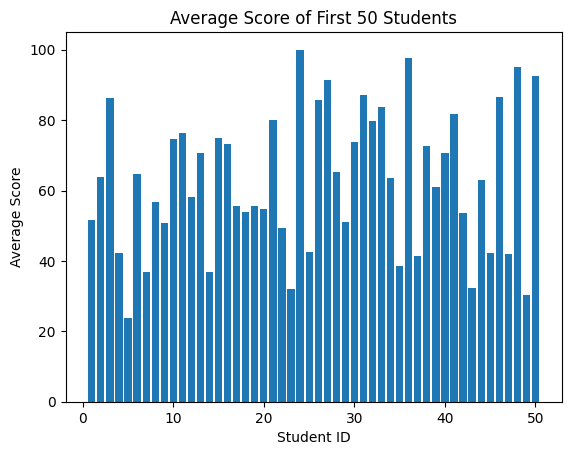

In [27]:
firstFifty=df.head(50)
plt.bar(firstFifty['student_id'], firstFifty['Average_Score'])

plt.title("Average Score of First 50 Students")
plt.xlabel("Student ID")
plt.ylabel("Average Score")
plt.savefig("bar_chart.png") 
plt.show()

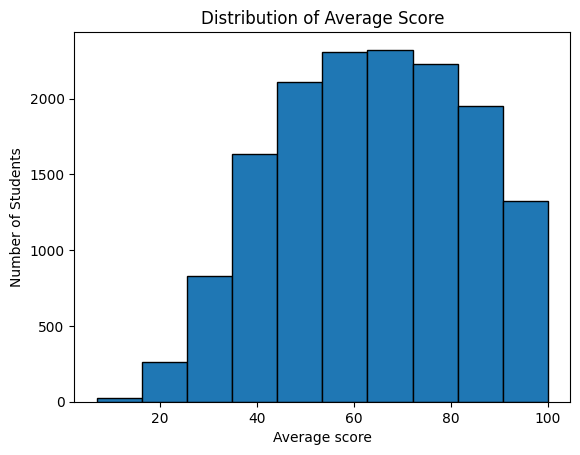

In [28]:
plt.hist(df['Average_Score'],bins=10,edgecolor='black')
plt.title('Distribution of Average Score')
plt.xlabel("Average score")
plt.ylabel("Number of Students")

plt.savefig("histogram.png")

<function matplotlib.pyplot.show(close=None, block=None)>

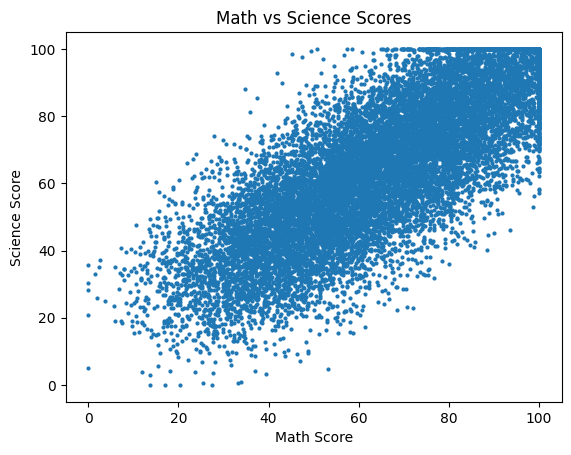

In [30]:
plt.scatter(df['Math'], df['Science'],s=4)

plt.title("Math vs Science Scores")
plt.xlabel("Math Score")
plt.ylabel("Science Score")
plt.savefig("scatter_plot.png")
plt.show

In [21]:
performance_count = df['Performance'].value_counts()

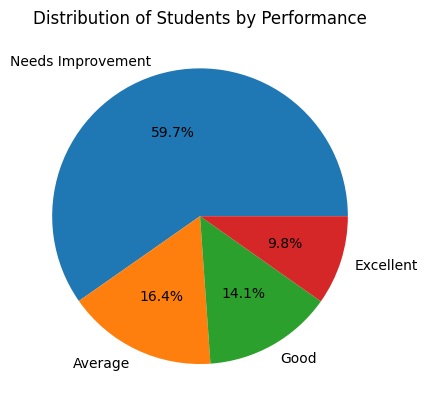

In [31]:
plt.pie(performance_count,
        labels=performance_count.index,
        autopct='%1.1f%%')

plt.title("Distribution of Students by Performance")
plt.savefig("pie_chart.png")

plt.show()

/tmp/ipykernel_100/2964377001.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


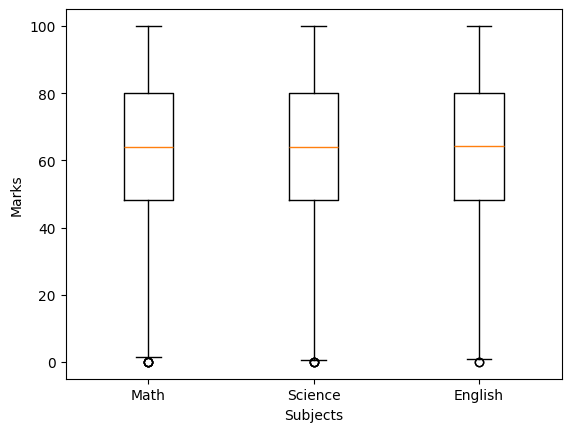

In [32]:
plt.boxplot([
    df['Math'],
    df['Science'],
    df['English']
],labels=['Math', 'Science', 'English'])

plt.xlabel("Subjects")
plt.ylabel("Marks")
plt.savefig("boxplot.png")
plt.show()